# HW2 Playground

Fill in TODOs as you work through the assignment.
Implement the required sections in `model.py`, and use this notebook to orchestrate and run your solution.

In [288]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from hw2_loader import HW2DataLoader
from hw1_model import HeartDiseaseClassifier
from model import GradientBoostingModel

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [289]:
# TODO: Load both datasets
loader = HW2DataLoader()

# Heart disease dataset
heart_path = Path('../data/heart.csv')
X_heart, y_heart = loader.get_heart_disease_data(csv_path=heart_path)
X_heart.drop_duplicates(inplace=True)
y_heart = y_heart[X_heart.index]
print(X_heart.shape, y_heart.value_counts().to_dict())

# check for missing values
print("Heart X missing values:", X_heart.isnull().sum().sum())
print("Heart Y missing values:", y_heart.isnull().sum())

# check that columns are all numeric
non_numeric_cancer = X_heart.select_dtypes(exclude=[np.number]).columns.tolist()
print("Heart non-numeric columns:", non_numeric_cancer)

# Cancer genomics dataset
cancer_path = Path('../data/cancer_genomics.csv')
labels_path = Path('../data/labels_cancer_genomics.csv')
X_cancer, y_cancer = loader.get_cancer_genomics_data(
    csv_path=cancer_path, labels_path=labels_path
)

print(X_cancer.shape, y_cancer.value_counts().to_dict())

# check for duplicates
X_cancer.drop_duplicates(inplace=True)
y_cancer = y_cancer[X_cancer.index]

# check for missing values
print("Cancer X missing values:", X_cancer.isnull().sum().sum())
print("Cancer Y missing values:", y_cancer.isnull().sum())

# check that columns are all numeric
non_numeric_cancer = X_cancer.select_dtypes(exclude=[np.number]).columns.tolist()
print("Cancer non-numeric columns:", non_numeric_cancer)


Successfully loaded heart disease data with 1025 rows
(302, 13) {1: 164, 0: 138}
Heart X missing values: 0
Heart Y missing values: 0
Heart non-numeric columns: []
(801, 5479) {'BRCA': 300, 'KIRC': 146, 'LUAD': 141, 'PRAD': 136, 'COAD': 78}
Cancer X missing values: 0
Cancer Y missing values: 0
Cancer non-numeric columns: []


In [294]:
# TODO: Initialize your model (adjust params)
heart_model = GradientBoostingModel(
    task='classification',
    max_depth=1,
    learning_rate=0.1,
    n_estimators=50,
    subsample=0.8,
    use_scaler=True,
)


In [295]:
# TODO: Train/test split + fit (heart)
Xh_train, Xh_test, yh_train, yh_test = heart_model.train_test_split(X_heart, y_heart)
heart_model.fit(Xh_train, yh_train)


accuracy     0.7868852459
precision    0.7941176471
recall       0.8181818182
f1           0.8059701493
roc_auc      0.8804112554
dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

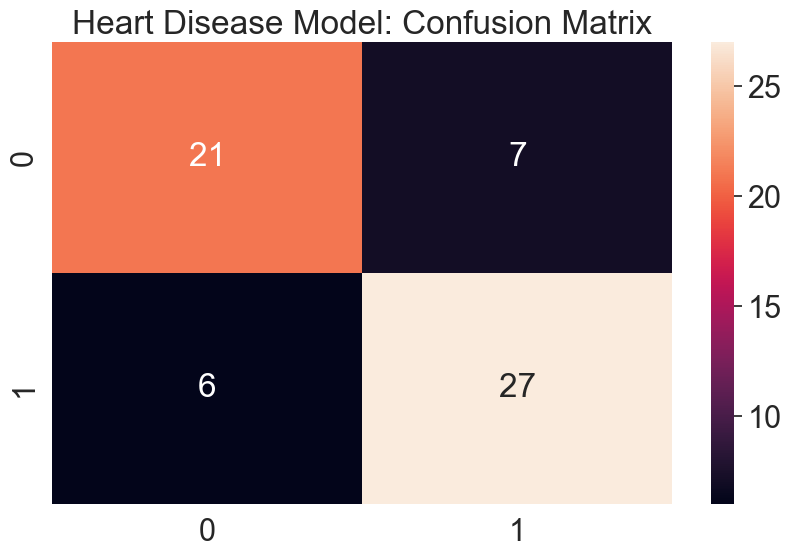

In [296]:
# TODO: Evaluate (heart)
heart_metrics = heart_model.evaluate(Xh_test, yh_test)
heart_metrics = pd.Series(heart_metrics).T
print(heart_metrics)

from sklearn.metrics import confusion_matrix
confusion_mat = confusion_matrix(yh_test, heart_model.predict(Xh_test))
sns.set_theme(font_scale=2)
sns.heatmap(confusion_mat, annot=True)
plt.title("Heart Disease Model: Confusion Matrix")
plt.show

In [297]:
# TODO: Cross-validation (heart)
heart_cv_results = heart_model.cross_validate(X_heart, y_heart)
heart_cv_results = pd.DataFrame(heart_cv_results).T
print(heart_cv_results)

                   mean           std
accuracy   0.8508743169  0.0643256444
precision  0.8372498090  0.0530139512
recall     0.9030303030  0.0752101433
f1         0.8679516125  0.0572395553
roc_auc    0.9137761544  0.0522978948


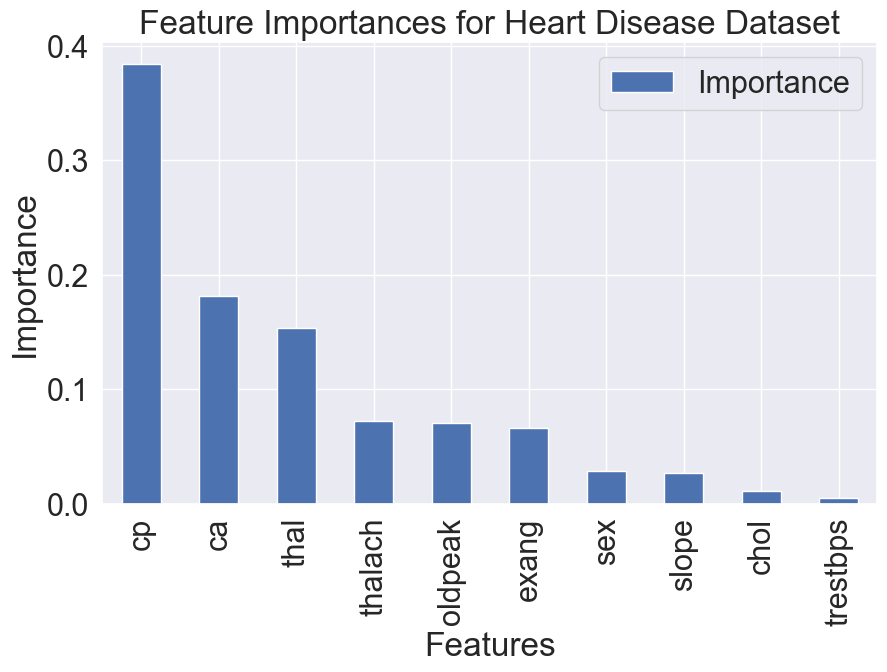

     Feature    Importance
2         cp  0.3841097770
11        ca  0.1815284201
12      thal  0.1534561647
7    thalach  0.0722696827
9    oldpeak  0.0706962895
8      exang  0.0657862258
1        sex  0.0284930698
10     slope  0.0270937078
4       chol  0.0111845065
3   trestbps  0.0053821560


In [298]:
# TODO: Feature importance (heart)
feature_importance = heart_model.get_feature_importance(plot=True, top_n=10)
print(feature_importance)


In [299]:
# TODO: Hyperparameter tuning (heart)
param_grid = {
    'max_depth': [1, 2, 3],
    'n_estimators': [50, 100, 500, 1000],
    'learning_rate': [0.1, 0.05, 0.01],
    'subsample' : [0.6, 0.8, 1.0]
}
tuning_results = heart_model.tune_hyperparameters(X_heart, y_heart, param_grid, cv=3)
print(pd.Series(tuning_results['best_params']))
print("Best Score: ", tuning_results['best_score'])

print(pd.concat([pd.DataFrame(tuning_results["results"]['params']),
                pd.DataFrame(tuning_results['results']['mean_test_score'], columns=["mean_test_score"])], 
                axis=1))


learning_rate     0.1
max_depth         1.0
n_estimators     50.0
subsample         0.8
dtype: float64
Best Score:  0.910040013663202
     learning_rate  max_depth  n_estimators  subsample  mean_test_score
0             0.10          1            50        0.6     0.9056653491
1             0.10          1            50        0.8     0.9100400137
2             0.10          1            50        1.0     0.9082332992
3             0.10          1           100        0.6     0.9036134290
4             0.10          1           100        0.8     0.9061996779
..             ...        ...           ...        ...              ...
103           0.01          3           500        0.8     0.8943346509
104           0.01          3           500        1.0     0.8894110184
105           0.01          3          1000        0.6     0.8948860587
106           0.01          3          1000        0.8     0.8901380959
107           0.01          3          1000        1.0     0.8821475626

[

In [287]:
# TODO: Train/evaluate on cancer dataset (multi-class)
cancer_model = GradientBoostingModel(
    task='classification',
    max_depth=1,
    learning_rate=0.2,
    n_estimators=50,
    use_scaler=True,
)
Xc_train, Xc_test, yc_train, yc_test = cancer_model.train_test_split(X_cancer, y_cancer)
# fit
cancer_model.fit(Xc_train, yc_train)
# evaluate
cancer_metrics = cancer_model.evaluate(Xc_test, yc_test)
cancer_metrics = pd.Series(cancer_metrics).T
print(cancer_metrics) 

accuracy     0.9813664596
precision    0.9815371372
recall       0.9813664596
f1           0.9811987061
roc_auc      0.9997984014
dtype: float64


    0   1   2   3   4
0  61   0   0   0   0
1   0  17   0   0   0
2   0   0  25   0   0
3   0   2   0  27   0
4   0   1   0   0  28


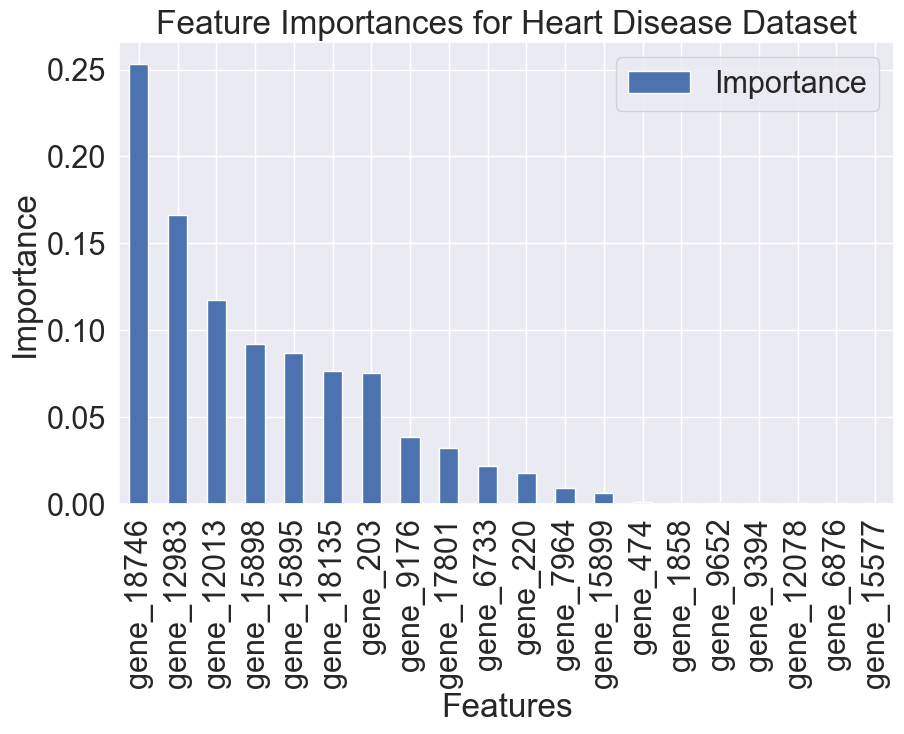

         Feature    Importance
5167  gene_18746  0.2531306791
3674  gene_12983  0.1663705098
3498  gene_12013  0.1171855374
4437  gene_15898  0.0923125236
4434  gene_15895  0.0867534491
5004  gene_18135  0.0767592548
57      gene_203  0.0754416695
2772   gene_9176  0.0388635707
4908  gene_17801  0.0324889939
1985   gene_6733  0.0217533172
62      gene_220  0.0179620074
2351   gene_7964  0.0094789112
4438  gene_15899  0.0061634968
154     gene_474  0.0009985287
526    gene_1858  0.0009319632
2919   gene_9652  0.0008606444
2833   gene_9394  0.0005972740
3525  gene_12078  0.0005927453
2032   gene_6876  0.0004552465
4330  gene_15577  0.0003666962


In [246]:
cancer_confusion_matrix = confusion_matrix(yc_test, cancer_model.predict(Xc_test))
print(pd.DataFrame(cancer_confusion_matrix))

feature_importance = cancer_model.get_feature_importance(plot=True, top_n=20)
print(feature_importance)


In [ ]:
cancer_param_grid = {
    'max_depth': [1, 2],
    'n_estimators': [50, 100],
    'learning_rate': [0.2, 0.1]
}
tuning_results = cancer_model.tune_hyperparameters(X_cancer, y_cancer, cancer_param_grid, cv=3)
print(pd.Series(tuning_results['best_params']))
print("Best Score: ", tuning_results['best_score'])

print(pd.concat([pd.DataFrame(tuning_results["results"]['params']),
                pd.DataFrame(tuning_results['results']['mean_test_score'], columns=["mean_test_score"])], 
                axis=1))

/Users/kelleytu/Documents/CS1851/homework-2-kelleytu/.hw2/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Users/kelleytu/Documents/CS1851/homework-2-kelleytu/.hw2/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/kelleytu/Documents/CS1851/homework-2-kelleytu/.hw2/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 317, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/kelleytu/Documents/CS1851/homework-2-kelleytu/.hw2/lib/python3.12/site-packages/sklearn/metrics/_score

learning_rate     0.2
max_depth         1.0
n_estimators     50.0
dtype: float64
Best Score:  nan


In [258]:
cancer_hw1_model = HeartDiseaseClassifier()
cancer_hw1_model.fit(Xc_train, yc_train)
ff_metrics = cancer_hw1_model.evaluate(Xc_test, yc_test)

num_k = 9
top_features = feature_importance['Feature'].head(num_k)
cancer_hw1_model_fs = HeartDiseaseClassifier(selected_features=top_features.tolist())
cancer_hw1_model_fs.fit(Xc_train, yc_train)
fs_metrics = cancer_hw1_model_fs.evaluate(Xc_test, yc_test)

cancer_hw1_model_lasso = HeartDiseaseClassifier(model_type="lasso")
cancer_hw1_model_lasso.fit(Xc_train, yc_train)
lasso_metrics = cancer_hw1_model_lasso.evaluate(Xc_test, yc_test)

print(pd.concat([pd.Series(fs_metrics), pd.Series(lasso_metrics), pd.Series(ff_metrics)],
                axis=1, 
                keys=["feature selection w/ GB", "feature selection w/ Lasso", "full-feature"]))


/Users/kelleytu/Documents/CS1851/homework-2-kelleytu/.hw2/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/kelleytu/Documents/CS1851/homework-2-kelleytu/.hw2/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/kelleytu/Documents/CS1851/homework-2-kelleytu/.hw2/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


           feature selection w/ GB  feature selection w/ Lasso  full-feature
accuracy                       1.0                         1.0           1.0
precision                      1.0                         1.0           1.0
recall                         1.0                         1.0           1.0
f1                             1.0                         1.0           1.0
auc                            1.0                         1.0           1.0
